# Introduction

Authors:
- [Jheam Storch Ross](jheam.ross@edu.ufes.br)

work about bla-bla-bla

Every # markdown session in this notebook is independent from the others, so you can run them in any order you want as long as the previous archifacts are available.

# Setup

## Download the database

In [90]:
data_dir = 'data'

!mkdir -p $data_dir

data_raw_dir = data_dir + '/raw'

!mkdir -p $data_raw_dir

data_raw = data_raw_dir + '/filmes.csv'

!wget --no-check-certificate -nc 'https://docs.google.com/uc?export=download&id=1AeYgV89TmYvNC__RDXr8hS0P6WOsChWg' -O $data_raw

File ‘data/raw/filmes.csv’ already there; not retrieving.


# Preprocessing

## Install the dependencies

In [91]:
%pip install \
    pandas \
    unidecode \
    spacy \
    matplotlib

!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Import the dataset

In [92]:
data_dir = 'data'
data_raw_dir = data_dir + '/raw'
data_raw = data_raw_dir + '/filmes.csv'

In [93]:
import pandas as pd

In [94]:
df = pd.read_csv(data_raw)
    #.sample(1, random_state=42)

In [95]:
df.shape

(30358, 9)

In [96]:
df.head()

,genres,averageRating,numVotes,sinopse,primaryTitle,startYear,runtimeMinutes,actors_names,directors_names
0,Family,7.1,387992,When two kids find and play a magical board ga...,Jumanji,1995,104,['Robin Williams' 'Jonathan Hyde' 'Jonathan Hy...,['Joe Johnston']
1,Romance,6.7,30265,John and Max resolve to save their beloved bai...,Grumpier Old Men,1995,101,['Walter Matthau' 'Jack Lemmon' 'Burgess Mered...,['Howard Deutch']
2,Romance,6.0,12585,"Based on Terry McMillan's novel, this film fol...",Waiting to Exhale,1995,124,['Gregory Hines' 'Dennis Haysbert' 'Mykelti Wi...,['Forest Whitaker']
3,"Romance,Family",6.1,42555,George Banks must deal not only with his daugh...,Father of the Bride Part II,1995,106,['Steve Martin' 'Martin Short' 'George Newbern...,['Charles Shyer']
4,"Crime,Action",8.3,738636,A group of high-end professional thieves start...,Heat,1995,170,['Al Pacino' 'Robert De Niro' 'Val Kilmer' 'Jo...,['Michael Mann']


In [97]:
df.isnull().sum()

# Como não há valores nulos, não removemos nenhuma linha

genres             0
averageRating      0
numVotes           0
sinopse            0
primaryTitle       0
startYear          0
runtimeMinutes     0
actors_names       0
directors_names    0
dtype: int64

## Preprocess

### Preprocess genres

In [98]:
df['genres_list'] = df['genres'].apply(lambda x: x.split(','))

<Axes: ylabel='count'>

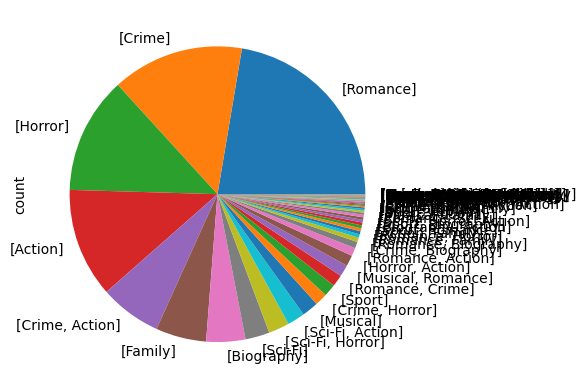

In [99]:
df['genres_list'].value_counts().plot(kind='pie')

<Axes: xlabel='genres_list'>

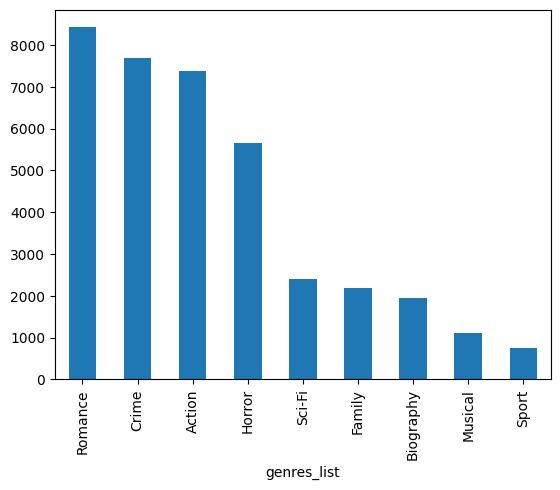

In [100]:
df['genres_list'].explode().value_counts().plot(kind='bar')

### Preprocess synopses

In [101]:
df['sinopse_clean'] = df['sinopse']

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,When two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,John and Max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...","Based on Terry McMillan's novel, this film fol..."
3,George Banks must deal not only with his daugh...,George Banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,A group of high-end professional thieves start...


In [102]:
# lower case
df['sinopse_clean'] = df['sinopse_clean'].apply(str.lower)

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,when two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,john and max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...","based on terry mcmillan's novel, this film fol..."
3,George Banks must deal not only with his daugh...,george banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,a group of high-end professional thieves start...


In [103]:
# normalize special characters

from unidecode import unidecode

df['sinopse_clean'] = [unidecode(c).lower() for c in df['sinopse_clean']]

# they are rare and I'm bad at pandas so I couldn't filter out the difference and show

In [104]:
# remove non-alpha and punctuation, except for apostrophes
import re

df['sinopse_clean'] = [re.sub(r'[^a-z\s\']', '', c) for c in df['sinopse_clean']]

df[['sinopse', 'sinopse_clean']].head()

,sinopse,sinopse_clean
0,When two kids find and play a magical board ga...,when two kids find and play a magical board ga...
1,John and Max resolve to save their beloved bai...,john and max resolve to save their beloved bai...
2,"Based on Terry McMillan's novel, this film fol...",based on terry mcmillan's novel this film foll...
3,George Banks must deal not only with his daugh...,george banks must deal not only with his daugh...
4,A group of high-end professional thieves start...,a group of highend professional thieves start ...


Here I tried to use the lingua-py package to remove non-english synopses.

The package identified 50, but the most of them were false positives.

So, I didn't use it.

In [105]:
import spacy

nlp = spacy.load('en_core_web_sm')

In [106]:
docs = [nlp(sinopse) for sinopse in df['sinopse_clean']]

In [107]:
# lemmatize and tokenize
df['sinopse_tokens'] = [[token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space] for doc in docs]

df[['sinopse_clean', 'sinopse_tokens']].head()

,sinopse_clean,sinopse_tokens
0,when two kids find and play a magical board ga...,"[kid, find, play, magical, board, game, releas..."
1,john and max resolve to save their beloved bai...,"[john, max, resolve, save, beloved, bait, shop..."
2,based on terry mcmillan's novel this film foll...,"[base, terry, mcmillan, novel, film, follow, d..."
3,george banks must deal not only with his daugh...,"[george, bank, deal, daughter, pregnancy, wife]"
4,a group of highend professional thieves start ...,"[group, highend, professional, thief, start, f..."


In [108]:
# tokenize (nltk)
#   ignore due to spacy lemmatization

#import nltk
#nltk.download('punkt_tab')
#
#df['sinopse_tokens'] = df['sinopse_clean'].apply(nltk.word_tokenize)
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

In [109]:
# remove aphostrophes
#   ignored due to lemmatization

#df['sinopse_tokens'] = df['sinopse_tokens'].apply(lambda x: [t for t in x if t != "'"])
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

In [110]:
# remove stopwords
#   ignore due to lemmatization

#nltk.download('stopwords')
#
#stop_words = set(nltk.corpus.stopwords.words('english'))
#
#df['sinopse_tokens'] = df['sinopse_tokens'].apply(lambda x: [w for w in x if not w in stop_words])
#
#df[['sinopse_clean', 'sinopse_tokens']].head()

## Save the preprocessed data

In [111]:
df.drop(columns=['sinopse_clean', 'sinopse', 'genres'], inplace=True)

In [112]:
data_processed_dir = data_dir + '/processed'

!mkdir -p $data_processed_dir

data_processed = data_dir + '/processed/filmes.csv'

df.to_csv(data_processed, index=False)

# Feature Engineering

## Install dependencies

In [113]:
%pip install\
    pandas\
    scikit-learn\
    umap-learn \
    matplotlib \
    seaborn

Note: you may need to restart the kernel to use updated packages.


## Load dataset

In [114]:
data_dir = 'data'
data_processed_dir = data_dir + '/processed'
data_processed = data_processed_dir + '/filmes.csv'

In [115]:
import pandas as pd

In [116]:
def convert_to_list(x):
    return [t.replace("'", "").replace('"', '') for t in x.strip("[]").split(", ")]

In [117]:
df = pd.read_csv(
    data_processed,
    converters={
        'genres_list': convert_to_list,
        'sinopse_tokens': convert_to_list
    })

df.shape

(30358, 9)

In [118]:
df.head()

,averageRating,numVotes,primaryTitle,startYear,runtimeMinutes,actors_names,directors_names,genres_list,sinopse_tokens
0,7.1,387992,Jumanji,1995,104,['Robin Williams' 'Jonathan Hyde' 'Jonathan Hy...,['Joe Johnston'],[Family],"[kid, find, play, magical, board, game, releas..."
1,6.7,30265,Grumpier Old Men,1995,101,['Walter Matthau' 'Jack Lemmon' 'Burgess Mered...,['Howard Deutch'],[Romance],"[john, max, resolve, save, beloved, bait, shop..."
2,6.0,12585,Waiting to Exhale,1995,124,['Gregory Hines' 'Dennis Haysbert' 'Mykelti Wi...,['Forest Whitaker'],[Romance],"[base, terry, mcmillan, novel, film, follow, d..."
3,6.1,42555,Father of the Bride Part II,1995,106,['Steve Martin' 'Martin Short' 'George Newbern...,['Charles Shyer'],"[Romance, Family]","[george, bank, deal, daughter, pregnancy, wife]"
4,8.3,738636,Heat,1995,170,['Al Pacino' 'Robert De Niro' 'Val Kilmer' 'Jo...,['Michael Mann'],"[Crime, Action]","[group, highend, professional, thief, start, f..."


## Re-preprocess

In [119]:
# documents num tokens

df['sinopse_tokens'].apply(len).describe()

count    30358.000000
mean        17.778279
std         14.423318
min          2.000000
25%         11.000000
50%         15.000000
75%         19.000000
max        500.000000
Name: sinopse_tokens, dtype: float64

I think that removing docs with too few tokens and too many tokens is a good idea. I will remove docs with less than 10 tokens (outliers 25%) and more than 20 tokens (outliers 75%).

In [120]:
# eliminate docs with less than 10 tokens and more than 20 tokens

#df = df[(df['sinopse_tokens'].apply(len) >= 10) & (df['sinopse_tokens'].apply(len) <= 20)]

#df.shape

Turns out it didn't affected the doc distribution at the dimensionality reduction phase that much, so I'm removing this step.

In [121]:
df['numVotes'].describe().apply(lambda x: format(x, 'f'))

count      30358.000000
mean       25055.050497
std        97916.577490
min            7.000000
25%          726.000000
50%         2156.000000
75%         8980.250000
max      2953990.000000
Name: numVotes, dtype: object

Maybe removing the most popular movies or the least popular movies could be a good idea.

In [122]:
#df = df[(df['numVotes'] >= 700) & (df['numVotes'] <= 9000)]

#df.shape

It would reduce the number of movies in half, but the shape of the distribution would be the same so, again, I think this is not a good idea.

In [123]:
df['sinopse_tokens_str'] = df['sinopse_tokens'].apply(lambda x: ' '.join(x))

## Tf-idf vectorization

In [124]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [125]:
vectorizer = TfidfVectorizer(
    # adjust for the preprocessed tokenized text
    token_pattern=r'(?u)\b\w+\b',
    lowercase=False,
    
    #ngram_range=(1, 2),
    max_df=.5,
    min_df=5,
    
    #sublinear_tf=True,
)

X_tfidf = vectorizer.fit_transform(df['sinopse_tokens_str'])

In [126]:
feature_names = vectorizer.get_feature_names_out()

len(feature_names)

9388

In [127]:
import matplotlib.pyplot as plt

In [128]:
# plot important n_terms
mean_tfidf = X_tfidf.mean(axis=0).A1

terms_scores = pd.DataFrame({
    'term': vectorizer.get_feature_names_out(),
    'score': mean_tfidf
})

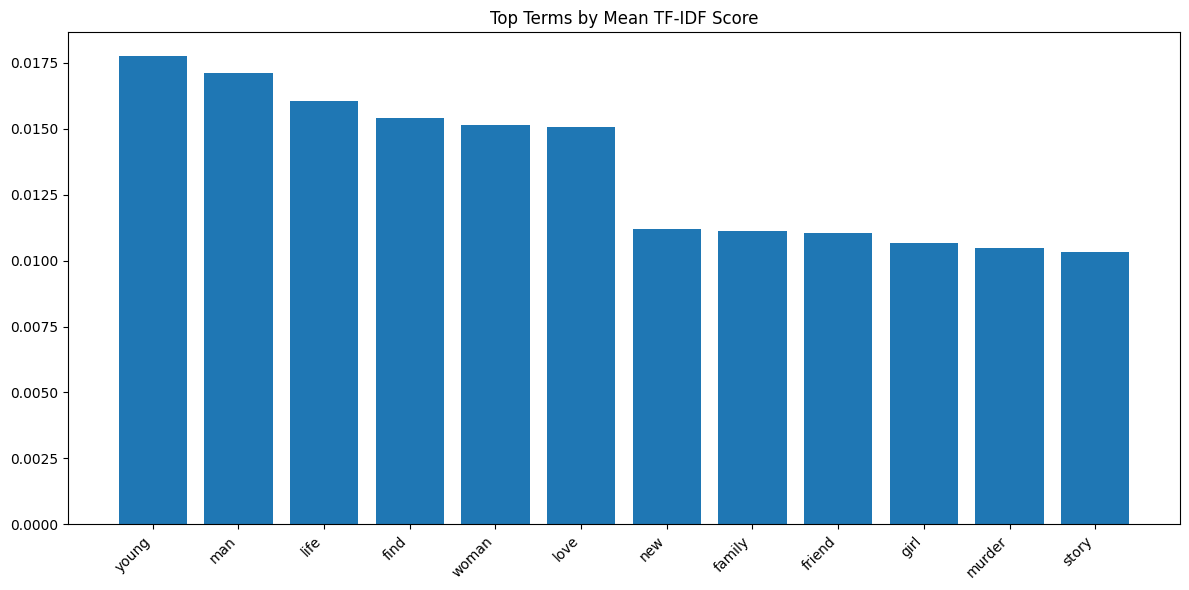

In [129]:
terms_scores = terms_scores.sort_values('score', ascending=False)

n_terms = 12

plt.figure(figsize=(12, 6))
plt.bar(terms_scores['term'][:n_terms], terms_scores['score'][:n_terms])
plt.xticks(rotation=45, ha='right')
plt.title('Top Terms by Mean TF-IDF Score')
plt.tight_layout()
plt.show()

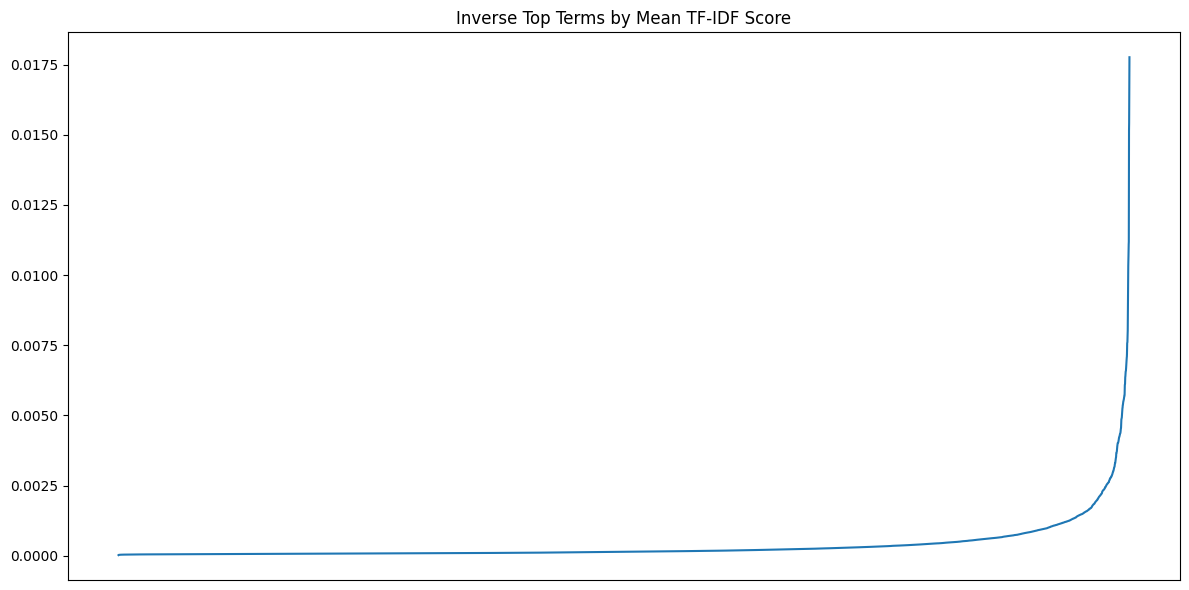

In [130]:
terms_scores = terms_scores.sort_values('score', ascending=True)

plt.figure(figsize=(12, 6))
plt.plot(terms_scores['term'], terms_scores['score'])
plt.title('Inverse Top Terms by Mean TF-IDF Score')
plt.xticks([])
plt.tight_layout()
plt.show()

Adjusting the max_df hyperparameter (and affter that I plotted the frequencies), I found out that most of the documents have a low frequency of words.

So, I focused in the min_df hyperparameter and other strategies to find the true nature of the data.

Turns out that everyting I tried didn't work.

## Dimensionality reduction

The best bet for a TfIdf matrix, which is a sparse matrix, is to use a TruncatedSVD, because PCA doesn't work well with sparse matrices.

### SVD

In [131]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

In [132]:
lsa_test = make_pipeline(TruncatedSVD(n_components=min(len(feature_names), 1000)), Normalizer(copy=False))
X_lsa = lsa_test.fit_transform(X_tfidf)

In [133]:
explained_variance = lsa_test[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Explained variance of the SVD step: 51.3%


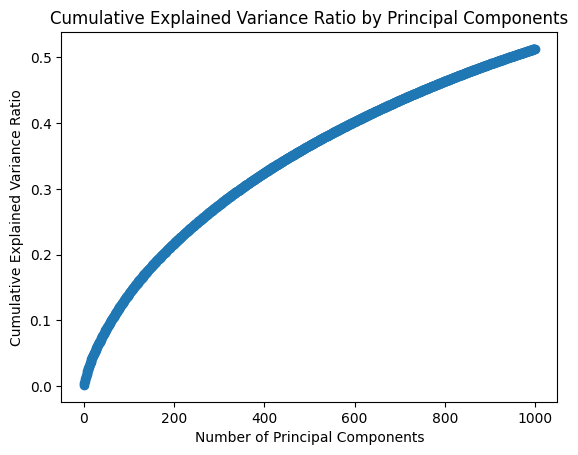

In [134]:
from matplotlib import pyplot as plt

cumulative_variance_ratio = np.cumsum(lsa_test[0].explained_variance_ratio_)
plt.plot(cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.show()

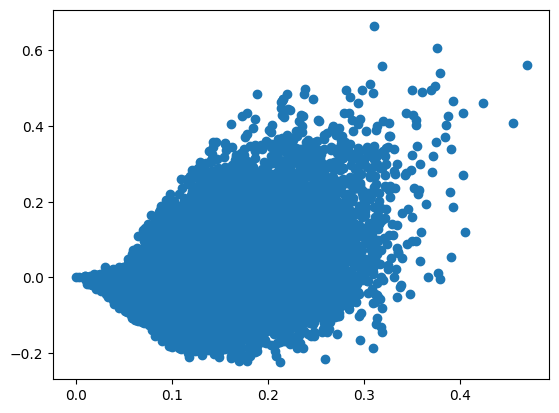

In [135]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1])

But, as the graph shows, the delta of explained variance is very low almost as a linear function.

Choosing a big number of components is not a good idea 'cause of the curse of dimensionality. So, I will choose 100 components, because it's a magic number that poped up in my mind and in some [scikit-learn articles](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html).

In [136]:
lsa = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)

In [137]:
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Explained variance of the SVD step: 13.8%


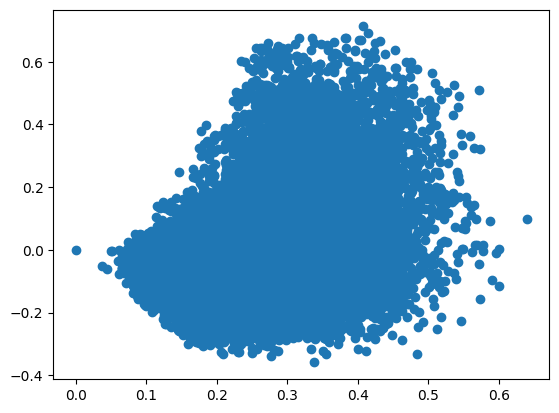

In [138]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1])

In [139]:
# VVVVVVVV
#
# useful to finding myterious outlier movies
# 
# ^^^^^^^^
# like german movies with german sinopses
# or the turkish adaptation of the wizard of oz

# assign each movie to a cluster of a single movie,
# the cluster label is the pair X, Y of the lsa

#df['unicluster'] = X_lsa[:, :2].tolist()

#df.where(df['unicluster'].apply(lambda x: x[0] < .005)).dropna()

The most likely reason for the low delta of explained variance are the weak correlations between the movies synopses or a high ammount of noise.

Noise that I can't explain or clean because it didn't matter if I had a tfidf matrix with 9000 features or 300 features,, neither if I chose a min_df of 5 or 0.01.

The SVD plot was always with the same shape.

### Non-linear dimensionality reduction

During my searches, one of the solutions for this problem (suggested by Claude LLM), could be the non-linear dimensionality reduction using NMF and tools like t-SNE or UMAP for visualization.

In [140]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler

In [141]:
nmf = make_pipeline(NMF(n_components=100), StandardScaler())
X_nmf = nmf.fit_transform(X_tfidf)

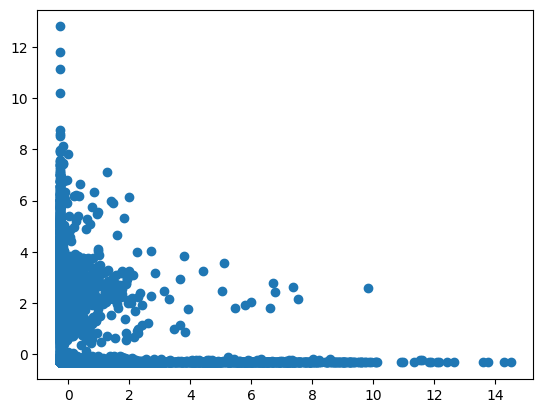

In [142]:
plt.scatter(X_nmf[:, 0], X_nmf[:, 1])

In [143]:
from umap import UMAP

In [144]:
umap = UMAP(n_components=2)
X_umap = umap.fit_transform(X_nmf)

/home/srjheam/projects/ufes-cdados-movie-synopsis-clustering/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


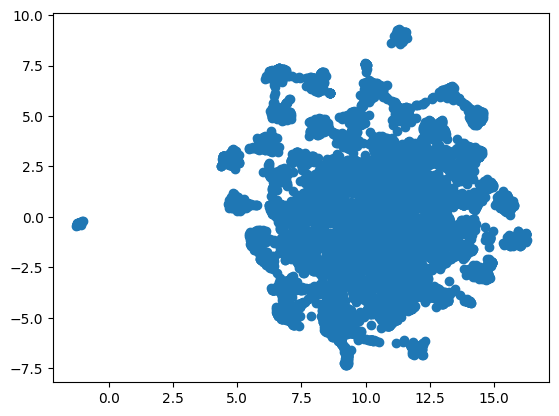

In [145]:
plt.scatter(X_umap[:, 0], X_umap[:, 1])

Well, well, well. This seems more promising than the previous SVD results.

I don't know if this is allowed but I will conduct an independent research of the NMF and the t-SNE/UMAP over SVD.

# Clusterization

### Hierarchical Clustering



#### Dendogramns everywhere

In [146]:
import scipy.cluster.hierarchy as hierarchy

In [147]:
Z = hierarchy.linkage(X_lsa, method='ward')

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [30.0, 30.0, 52.5, 52.5],
  [75.0, 75.0, 85.0, 85.0],
  [41.25, 41.25, 80.0, 80.0],
  [10.0, 10.0, 60.625, 60.625],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [95.0, 95.0, 112.5, 112.5],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [165.0, 165.0, 182.5, 182.5],
  [142.5, 142.5, 173.75, 173.75],
  [103.75, 103.75, 158.125, 158.125],
  [205.0, 205.0, 215.0, 215.0],
  [225.0, 225.0, 235.0, 235.0],
  [265.0, 265.0, 275.0, 275.0],
  [255.0, 255.0, 270.0, 270.0],
  [245.0, 245.0, 262.5, 262.5],
  [230.0, 230.0, 253.75, 253.75],
  [210.0, 210.0, 241.875, 241.875],
  [285.0, 285.0, 295.0, 295.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [290.0, 290.0, 312.5, 312.5],
  [335.0, 335.0, 345.0, 345.0],
  [355.0, 355.0, 365.0, 365.0],
  [340.0, 340.

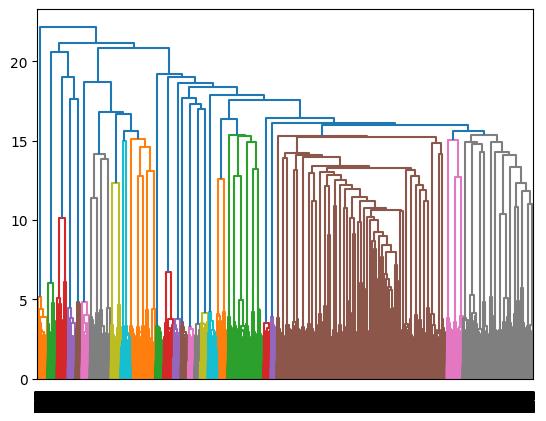

In [148]:
hierarchy.dendrogram(Z)

Looking at the dendrogram, I caught my self in a profound thought process to find out the optimal number of clusters.

Turns out my roomate knocked on my door asking me about something and before our farewell I asked him a random number between 5 and 15.

This is real data science done by a real data scientist.

He said 6 and that's what I'm going to use for the KMeans algorithm (and also the hierarchical clustering).

#### Clustering Hierarchical

In [149]:
from sklearn.cluster import AgglomerativeClustering

m = AgglomerativeClustering(n_clusters=6, linkage='ward')
m.fit(X_lsa)

AgglomerativeClustering(n_clusters=6)

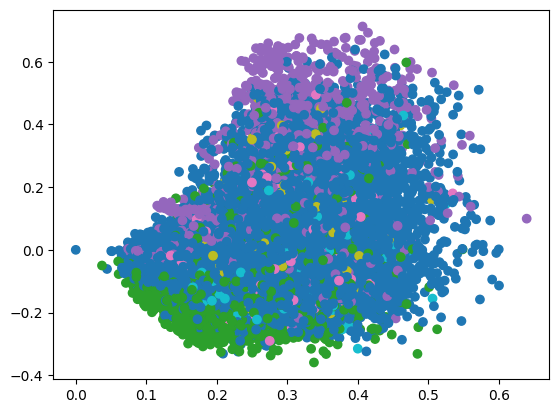

In [150]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=m.labels_, cmap='tab10')

Beautiful. But not right.

My roomate's fault.

Maybe the bottom group and the top one makes sense, but the middle ones are a mess.

I'll try it with 4 clusters. (don't tell him I don't gave him the chance to say 4)

In [151]:
m_4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
m_4.fit(X_lsa)

AgglomerativeClustering(n_clusters=4)

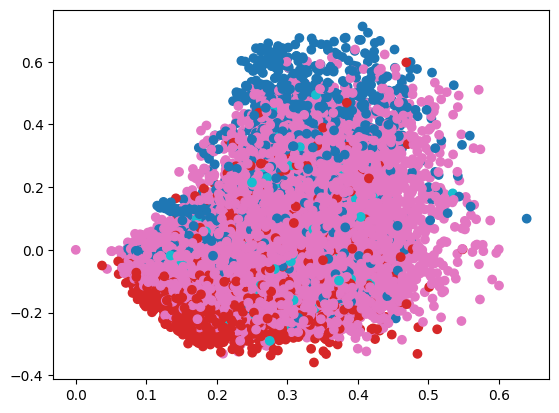

In [152]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=m_4.labels_, cmap='tab10')

The middle ones are merged. It seems that 3 clusters is the best choice.

In [153]:
m_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
m_3.fit(X_lsa)

AgglomerativeClustering(n_clusters=3)

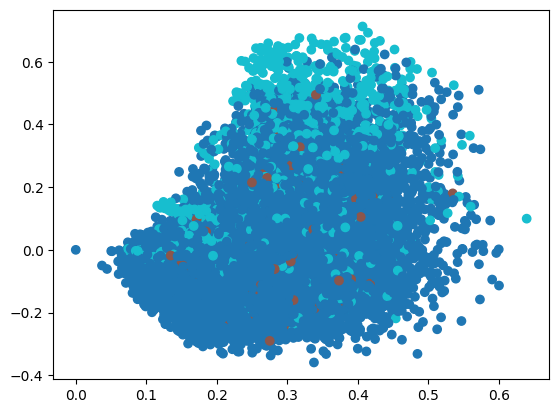

In [154]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=m_3.labels_, cmap='tab10')

Okay, I was not expecting that.

The bottom and top groups grew in size and the middle is still a mess.

#### What about the NMF + umap?

In [155]:
Z_umap = hierarchy.linkage(X_nmf, method='ward')

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [5.0, 5.0, 22.5, 22.5],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [45.0, 45.0, 63.75, 63.75],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [102.5, 102.5, 132.5, 132.5],
  [54.375, 54.375, 117.5, 117.5],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [175.0, 175.0, 192.5, 192.5],
  [165.0, 165.0, 183.75, 183.75],
  [155.0, 155.0, 174.375, 174.375],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [245.0, 245.0, 255.0, 255.0],
  [265.0, 265.0, 275.0, 275.0],
  [250.0, 250.0, 270.0, 270.0],
  [285.0, 285.0, 295.0, 295.0],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [355.0, 355.0, 365.0, 365.0],
  [332.5, 332.5, 360.0, 360.0],
  [315.0, 315.0, 346.25, 346.25],
  [305.0, 305.0, 330.625, 330.625],
  [290.0, 290.0, 317.8125, 317.8125],
  [395.0

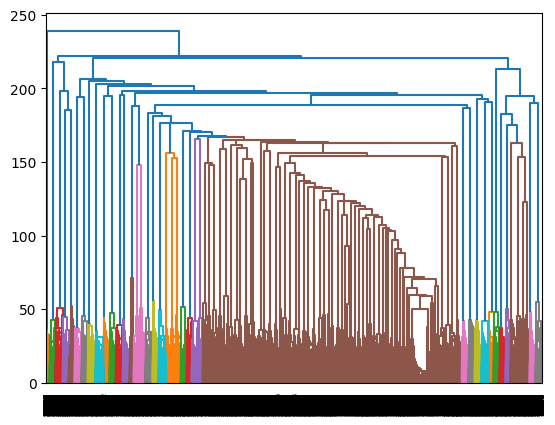

In [156]:
hierarchy.dendrogram(Z_umap)

I asked my roomate to come back one more time, but to choose a number between 3 and 9.

He said 6 again.

But I'll go with 4, because I'm the data scientist here.

In [157]:
m_nmf = AgglomerativeClustering(n_clusters=4, linkage='ward')
m_nmf.fit(X_nmf)

AgglomerativeClustering(n_clusters=4)

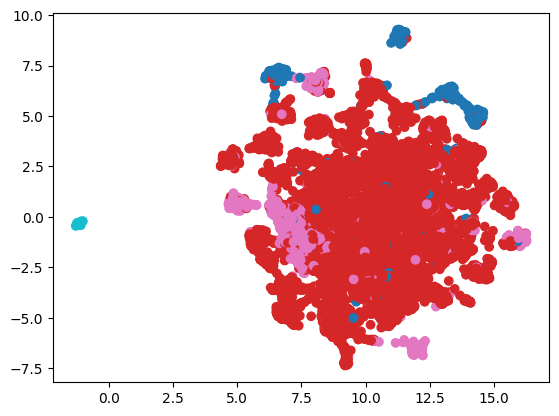

In [158]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=m_nmf.labels_, cmap='tab10')

Hmmmm. I'd like that the islands were a group each. And not that distant islands were in the same group just because they are different from the others or the main island.

Although I think that this is very promising.

Now I'll just count the islands in my head and try again.

In [159]:
m_nmf_30 = AgglomerativeClustering(n_clusters=30, linkage='ward')
m_nmf_30.fit(X_nmf)

AgglomerativeClustering(n_clusters=30)

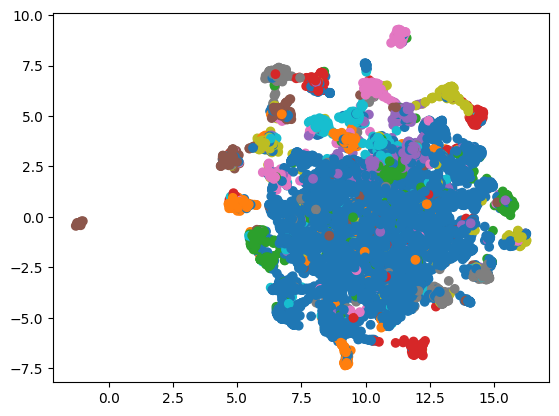

In [160]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=m_nmf_30.labels_, cmap='tab10')

Ok, it seems that the satellites continue in the same group but increasing the number of clusters springs up many little islands in what it seem to be the main island.

I'll go with 100 clusters.

In [161]:
m_nmf_100 = AgglomerativeClustering(n_clusters=100, linkage='ward')
m_nmf_100.fit(X_nmf)

AgglomerativeClustering(n_clusters=100)

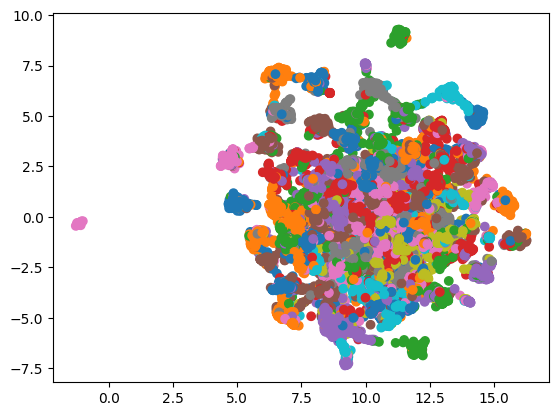

In [162]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=m_nmf_100.labels_, cmap='tab10')

Colorful.

## Spectral Clustering

My final hope

In [ ]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from numpy import linalg as LA

In [ ]:
G = kneighbors_graph(X_lsa, n_neighbors = 10, include_self = True)
A = 0.5 * (G + G.T)

L = csgraph.laplacian(A, normed = True).todense()

values, _ = LA.eigh(L)

plt.scatter([i for i in range(1, 21)], values[:20])
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue');

In [ ]:
optimal_k = plot_all_silhouettes(X_lsa, max_clusters=6)

In [ ]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=sm_6.labels_, cmap='tab10')

AttributeError: 'SpectralClustering' object has no attribute 'labels_'

### KMeans

In [163]:
from collections import defaultdict
from time import time
from sklearn import metrics

In [165]:
from sklearn.cluster import KMeans

In [169]:
n_clusters = 6

km = KMeans(n_clusters)
km.fit(X_lsa)

KMeans(n_clusters=6)

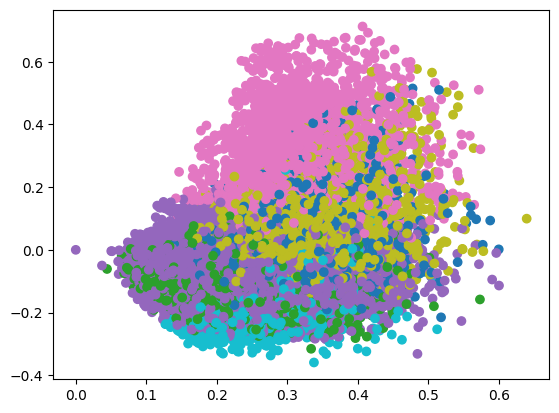

In [170]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=km.labels_, cmap='tab10')

In [171]:
n_clusters = 4

km = KMeans(n_clusters)
km.fit(X_lsa)

KMeans(n_clusters=4)

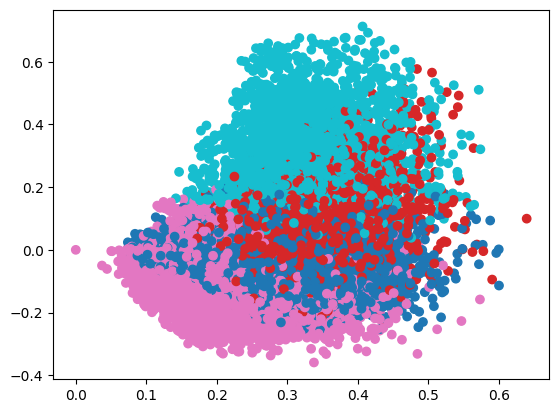

In [172]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=km.labels_, cmap='tab10')

In [173]:
n_clusters = 3

km = KMeans(n_clusters)
km.fit(X_lsa)

KMeans(n_clusters=3)

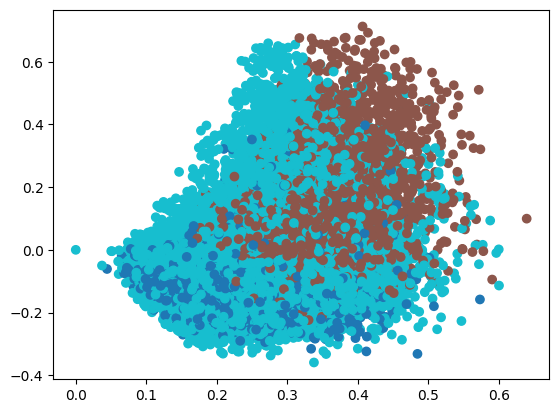

In [174]:
plt.scatter(X_lsa[:, 0], X_lsa[:, 1], c=km.labels_, cmap='tab10')

#### KMeans with NMF + UMAP

In [175]:
n_clusters = 30

km_nmf_30 = KMeans(n_clusters)
km_nmf_30.fit(X_nmf)

KMeans(n_clusters=30)

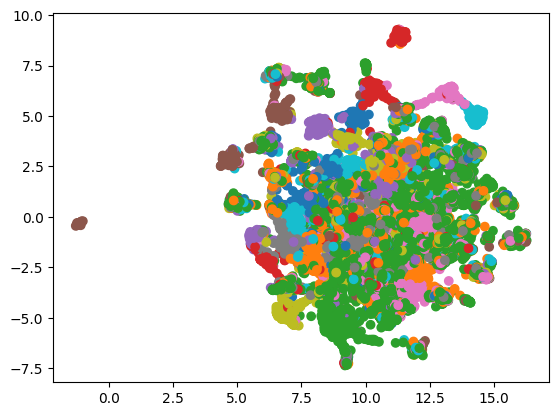

In [176]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=km_nmf_30.labels_, cmap='tab10')

In [177]:
n_clusters = 100

km_nmf_100 = KMeans(n_clusters)
km_nmf_100.fit(X_nmf)

KMeans(n_clusters=100)

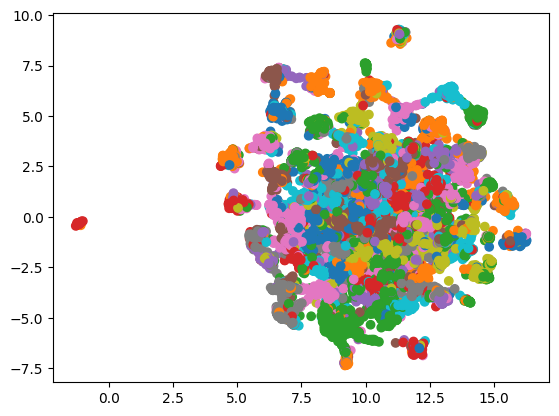

In [178]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=km_nmf_100.labels_, cmap='tab10')

# Results

KeyboardInterrupt: 

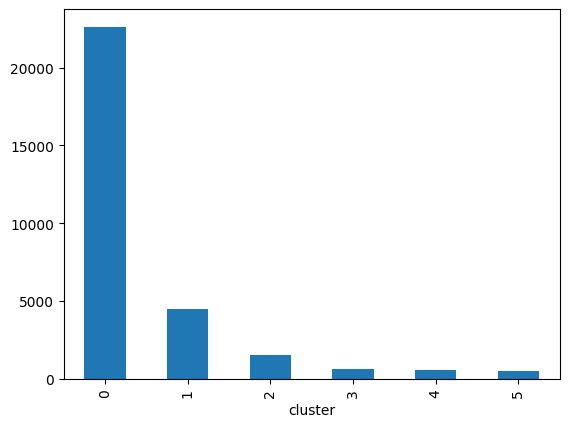

In [4]:
df['cluster'] = m.labels_
df['cluster'].value_counts().plot(kind='bar')

# show each cluster's genres

df['cluster_genres'] = df['cluster'].apply(lambda x: df[df['cluster'] == x]['genres_list'].explode().value_counts())

# Summary

## Validação

### Como foi escolhido o número de componentes principais para o PCA?

Visualizando o gráfico de variância explicada, percebi que o delta de variância explicada é muito baixo, quase como uma função linear.

Assim, escolher poucos ou escolher muitos componentes não fazia diferença porque a distribuição dos dados se mantinha a mesma.

Escolhi 100 componentes porque é um número mágico que surgiu na minha cabeça e em alguns [artigos do scikit-learn](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html).

### O número de componentes principais tem um impacto signicativo nos resultados?

Não.

Pela variância explicada, seu delta é muito pequeno.

Escollher 100 ou 1000 componentes não fazia diferença na distribuição dos dados.

### É necessário usar PCA neste trabalho?

PCA em si não é possível de ser usado com matrizes esparsas, como a matriz tfidf.

Mas o TruncatedSVD é uma alternativa para matrizes esparsas de redução de dimensionalidade é importante para fugir da maldição da dimensionalidade.

Ainda, durante o trabalho entrei em contato com o NMF, que é uma ferramenta não-linear de redução da dimensionalidade, e visualmente (com UMAP) ele se mostrou mais promissor que o SVD.

### Como o número de grupos para cada algoritmo de agrupamento foi definido?

Para o agrupamento hierárquico, usei a visualização do dendograma e a escolha de um número de clusters que fizesse sentido (para o meu amigo Ricardo, haha).

Para o KMeans, eu comecei com os mesmos clusters do dendograma, mas também apliquei a (análise de silhueta)[https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py].

Para o agrupamento espectral, segui a análise de silhueta.

### A escolha do algoritmo de agrupamento impacta signicativamente os resultados?



#### E o número de grupos?



## Análise

### Há diferença nas distribuições de gêneros dos filmes em grupos diferentes?



### Há relação entre as sinopses dos filmes e os respectivos gêneros?



### Se, além das sinopses, também se considerar as demais informações no conjunto de dados (avaliações, atores/atrizes, diretores(as), título, ano e duração) para os algoritmos de agrupamento, é possível encontrar uma melhor associação entre os grupos e os gêneros dos filmes? 



# TODO: apagar

In [179]:
%pip install dill

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 1.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [180]:
import dill
dill.dump_session('notebook_env.db')

In [1]:
import dill
dill.load_session('notebook_env.db')

/home/srjheam/projects/ufes-cdados-movie-synopsis-clustering/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
